In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# EDA

## Overview

In [33]:
df = pd.read_csv('../data/raw/Product Data.csv', sep=';', encoding='utf-8-sig')
df

,No_,Nazwa_PL,Skład_PL,Opis_PL,Nazwa_EN,Skład_EN,Opis_EN,Gender,Gramatura,Net Weight,PVS Item Type Code$5452f323-059e-499a-9753-5d2c07eef904,PVS Item Quality Code$5452f323-059e-499a-9753-5d2c07eef904,PVS Quality Type Code$5452f323-059e-499a-9753-5d2c07eef904
0,GAB/00311/L335,NaN,NaN,NaN,Long White Cooking Apron with Front Pocket,100% Cotton/Cotton twill,"Long white cooking apron with front pocket, 60...",NaN,180,"0,16",OT,OTF,OR
1,GAB/00512/01,Torba na Zakupy z Krótkimi Uszami,100% Bawełna,"Długość uszu: 35 x 2,5 cm.",Shopping Bag with Short Handles,100% Cotton,"Handles: 35 x 2,5 cm.",NaN,140,"0,069",TO,TOZB,NaN
2,GAB/00512/02,Torba na Zakupy z Krótkimi Uszami,100% Bawełna,"Długość uszu: 35 x 2,5 cm.",Shopping Bag with Short Handles,100% Cotton,"Handles: 35 x 2,5 cm.",NaN,140,"0,069",TO,TOZB,NaN
3,GAB/00512/03,Torba na Zakupy z Krótkimi Uszami,100% Bawełna,"Długość uszu: 35 x 2,5 cm.",Shopping Bag with Short Handles,100% Cotton,"Handles: 35 x 2,5 cm.",NaN,140,"0,069",TO,TOZB,NaN
4,GAB/00512/04,Torba na Zakupy z Krótkimi Uszami,100% Bawełna,"Długość uszu: 35 x 2,5 cm.",Shopping Bag with Short Handles,100% Cotton,"Handles: 35 x 2,5 cm.",NaN,140,"0,069",TO,TOZB,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
294125,TYO/YK910/N399/4,NaN,NaN,NaN,Hi-Vis Top Cool Super Light V-Neck T-Shirt,100% Polyester,Top cool V-neck mesh high visibility T-shirt. ...,U,130,"0,199",OT,OTO,OR
294126,TYO/YK910/N399/5,NaN,NaN,NaN,Hi-Vis Top Cool Super Light V-Neck T-Shirt,100% Polyester,Top cool V-neck mesh high visibility T-shirt. ...,U,130,"0,205",OT,OTO,OR
294127,TYO/YK910/N399/6,NaN,NaN,NaN,Hi-Vis Top Cool Super Light V-Neck T-Shirt,100% Polyester,Top cool V-neck mesh high visibility T-shirt. ...,U,130,"0,213",OT,OTO,OR
294128,TYO/YK910/N399/7,NaN,NaN,NaN,Hi-Vis Top Cool Super Light V-Neck T-Shirt,100% Polyester,Top cool V-neck mesh high visibility T-shirt. ...,U,130,"0,218",OT,OTO,OR


In [34]:
df.describe(include='all')

,No_,Nazwa_PL,Skład_PL,Opis_PL,Nazwa_EN,Skład_EN,Opis_EN,Gender,Gramatura,Net Weight,PVS Item Type Code$5452f323-059e-499a-9753-5d2c07eef904,PVS Item Quality Code$5452f323-059e-499a-9753-5d2c07eef904,PVS Quality Type Code$5452f323-059e-499a-9753-5d2c07eef904
count,294130,266555,266570,266268,273074,273074,272835,250562,294130.000000,294130,293144,294122,82263
unique,294130,19747,5637,21643,19268,5533,20349,4,NaN,1925,35,205,9
top,GAB/00311/L335,Damska Koszulka Basic,100% Bawełna,Wszyty rękaw. Ściągacz 1x1 przy kołnierzyku. W...,College Hoodie,100% Cotton,Set-in sleeve. 1x1 rib at neck collar. Inside ...,M,NaN,0,TS,TSK,OR
freq,1,805,30412,632,561,28033,814,105298,NaN,20720,71529,60778,25786
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,163.424510,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,114.233658,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,180.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,260.000000,NaN,NaN,NaN,NaN


## Duplicates and missing values

In [35]:
print(df['No_'].duplicated().sum())

missing = (df.isna().agg(['sum', 'mean']).T.rename(columns={'sum': 'missing_count', 'mean': 'missing_ratio'}))
missing['missing_ratio'] = (missing['missing_ratio'] * 100).round(2)
missing.sort_values('missing_ratio', ascending=False)

0


,missing_count,missing_ratio
PVS Quality Type Code$5452f323-059e-499a-9753-5d2c07eef904,211867.0,72.03
Gender,43568.0,14.81
Opis_PL,27862.0,9.47
Nazwa_PL,27575.0,9.38
Skład_PL,27560.0,9.37
Opis_EN,21295.0,7.24
Nazwa_EN,21056.0,7.16
Skład_EN,21056.0,7.16
PVS Item Type Code$5452f323-059e-499a-9753-5d2c07eef904,986.0,0.34
No_,0.0,0.00


In [67]:
nan_cols = ['Opis_PL', 'Nazwa_PL', 'Nazwa_EN', 'Opis_EN']
mask_nan = (df[nan_cols].fillna('').apply(lambda x: x.str.strip()).eq('').all(axis=1))
mask_nan.sum()

np.int64(9520)

## Text data

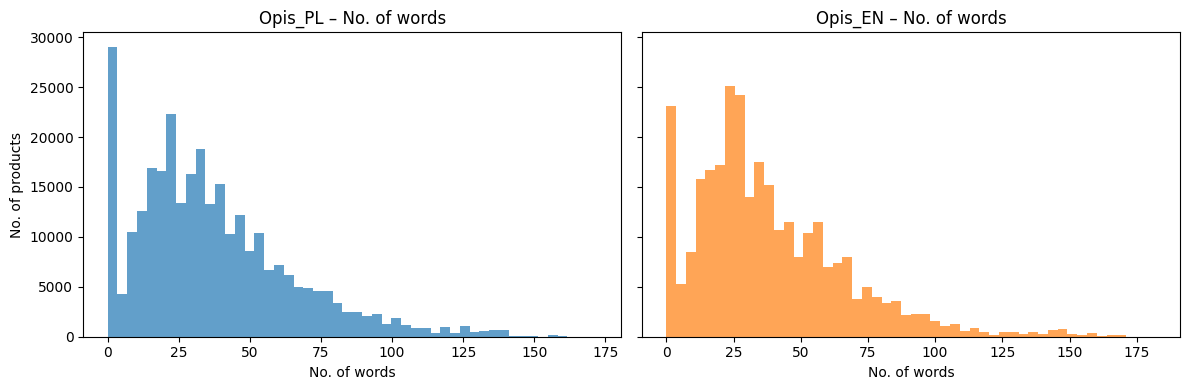

In [54]:
text_cols_pl = ["Nazwa_PL", "Skład_PL", "Opis_PL"]
text_cols_en = ["Nazwa_EN", "Skład_EN", "Opis_EN"]
text_cols = text_cols_pl + text_cols_en

for col in text_cols:
    df[col + "_len_chars"] = df[col].fillna("").str.len()
    df[col + "_len_words"] = df[col].fillna("").str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

axes[0].hist(df["Opis_PL_len_words"], bins=50, color="tab:blue", alpha=0.7)
axes[0].set_title("Opis_PL – No. of words")
axes[0].set_xlabel("No. of words")
axes[0].set_ylabel("No. of products")

axes[1].hist(df["Opis_EN_len_words"], bins=50, color="tab:orange", alpha=0.7)
axes[1].set_title("Opis_EN – No. of words")
axes[1].set_xlabel("No. of words")

plt.tight_layout()
plt.show()

In [44]:
df[[col + "_len_words" for col in text_cols]].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.99]).round(0)

,Nazwa_PL_len_words,Skład_PL_len_words,Opis_PL_len_words,Nazwa_EN_len_words,Skład_EN_len_words,Opis_EN_len_words
count,294130.0,294130.0,294130.0,294130.0,294130.0,294130.0
mean,4.0,4.0,37.0,4.0,4.0,38.0
std,2.0,4.0,28.0,2.0,4.0,28.0
min,0.0,0.0,0.0,0.0,0.0,0.0
25%,3.0,2.0,18.0,3.0,2.0,19.0
50%,4.0,3.0,31.0,4.0,3.0,32.0
75%,5.0,4.0,52.0,5.0,5.0,53.0
90%,7.0,8.0,75.0,6.0,9.0,75.0
99%,11.0,18.0,127.0,9.0,22.0,139.0
max,20.0,40.0,172.0,17.0,39.0,182.0


## Categorical data

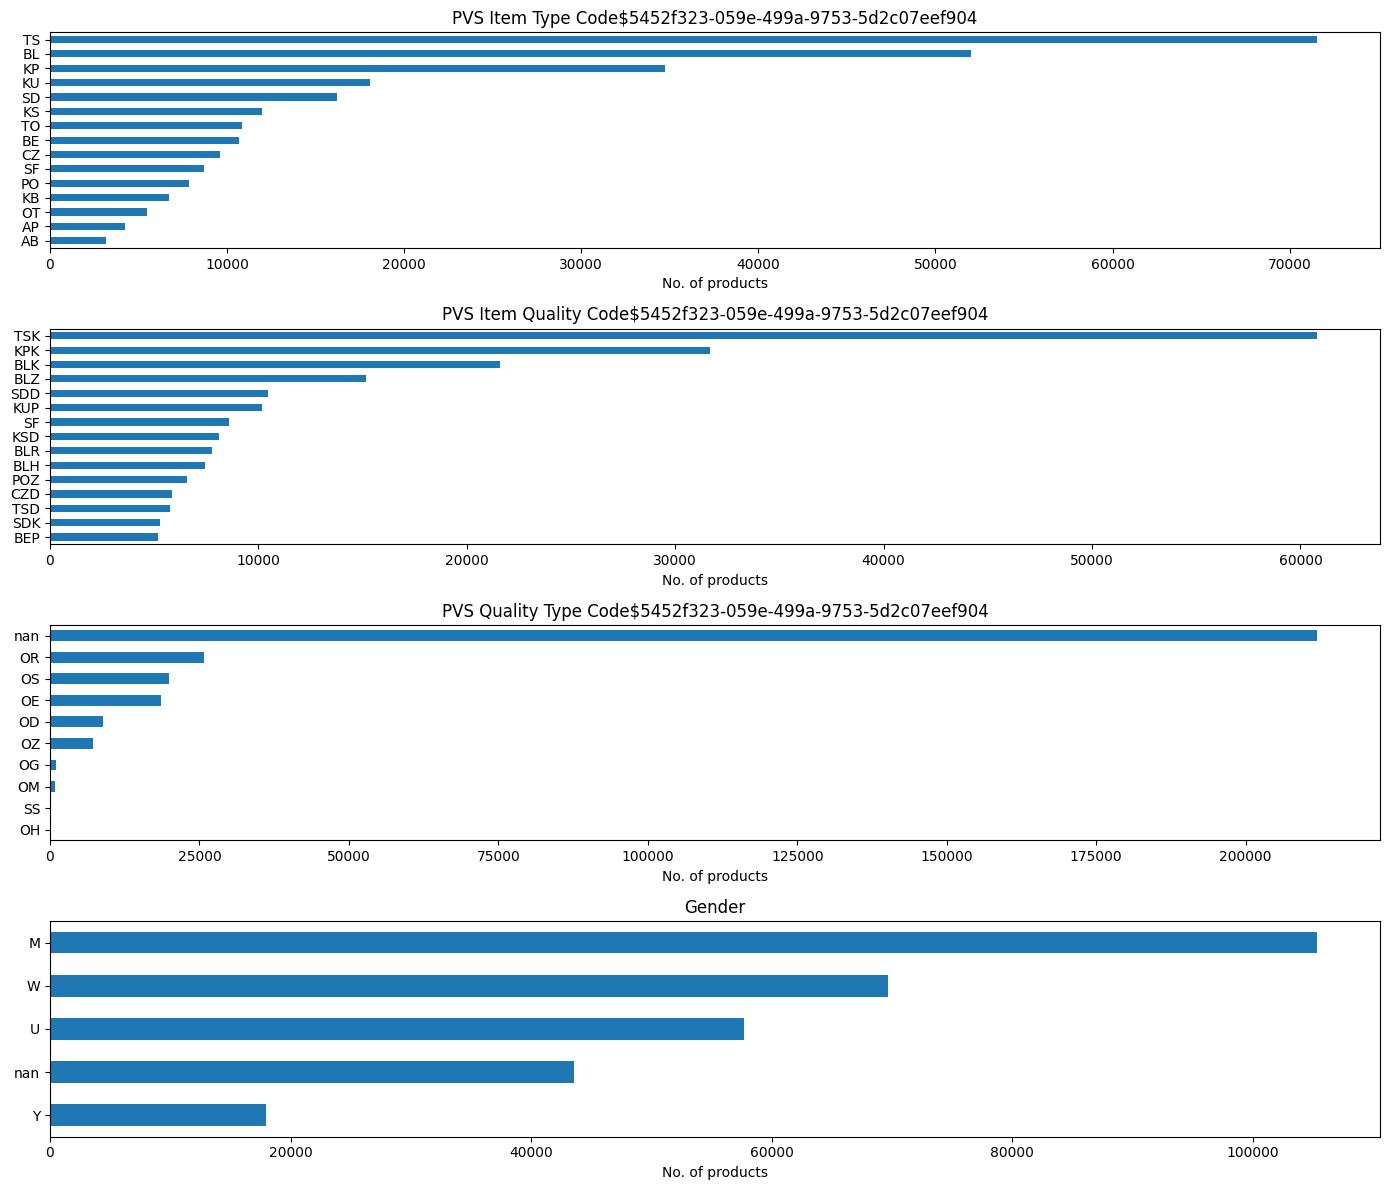

In [61]:
cols_to_plot = [
    "PVS Item Type Code$5452f323-059e-499a-9753-5d2c07eef904",
    "PVS Item Quality Code$5452f323-059e-499a-9753-5d2c07eef904",
    "PVS Quality Type Code$5452f323-059e-499a-9753-5d2c07eef904",
    "Gender"
]
top_n = 15

fig, axes = plt.subplots(4, 1, figsize=(14, 12))
axes = axes.ravel()

for ax, col in zip(axes, cols_to_plot):
    vc = df[col].value_counts(dropna=False).head(top_n)
    vc.plot(kind="barh", ax=ax, color="tab:blue")
    ax.invert_yaxis()
    ax.set_title(col)
    ax.set_xlabel("No. of products")
    ax.set_ylabel("")

plt.tight_layout()
plt.show()

In [65]:
print(list(df[cols_to_plot[1]].unique()))

['OTF', 'TOZB', 'TOJ', 'TOZ', 'TOA', 'TOE', 'TOG', 'PAK', 'TOL', 'TOP', 'PAS', 'KBS', 'DUMMY', 'KBZ', 'KBC', 'KBA', 'TDK', 'KBI', 'CZZ', 'AZS', 'CZD', 'CZK', 'CZM', 'CZW', 'CZI', 'TOF', 'RSY', 'TOY', 'ABO', 'APK', 'NAM', 'ABN', 'SSO', 'TOM', 'ADG', 'ABR', 'ABB', 'ABG', 'BRT', 'ABU', 'NBN', 'TOK', 'ACC', 'ACL', 'RSG', 'AKD', 'BIS', 'SSG', 'ADI', 'APA', 'AKU', 'ACG', 'ACB', 'ACT', 'ADL', 'RSQ', 'NAJ', 'FKZ', 'KBB', 'KBN', 'KBX', 'AKW', 'AKP', 'AKS', 'AKN', 'RSH', 'AKO', 'BRK', 'ABS', 'ABE', 'FKA', 'APE', 'TOB', 'BRL', 'NAW', 'RSR', 'APZ', 'API', 'APC', 'APF', 'APG', 'APP', 'APH', 'APO', 'RSP', 'NAZ', 'RSI', 'RSN', 'TOS', 'TDR', 'RSJ', 'OTO', 'ZBO', 'FKM', 'TOI', 'TON', 'RSO', 'TOC', 'ABP', 'NAT', 'NAL', 'NAN', 'PAG', 'KUW', 'ACU', 'ADD', 'KBF', 'TOH', 'TOW', 'ACE', 'CZS', 'AZO', 'AZR', 'AZZ', 'CZV', 'CZY', 'AKZ', 'BRZ', 'ABK', 'ZBM', 'FKG', 'BRA', 'TSK', 'OTM', 'ACM', 'ZBI', 'OBL', 'BRN', 'KUE', 'ACY', 'BRB', 'AMI', 'KPK', 'SDD', 'ADP', 'ABT', 'AKI', 'GLP', 'NBD', 'ACI', 'OTA', 'POZ', 'C